In [1]:
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
  from google.colab import drive

  drive.mount('/content/drive') # load google drive
  os.chdir('/content/drive/My Drive/Thesis_Repository/Final_Google_Drive') # change directory to the current working directory

Mounted at /content/drive


### 1. Settings

In [2]:
import json
import re
import random
import os
from pathlib import Path
from pprint import pprint

import yaml

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    roc_auc_score,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)


FINETUNING_CONFIG_PATH = Path("./configs/finetuning__wce__n_turns.yaml")
DATA_PATH = Path("./data/stepverify__all_turns.csv")
CHECKPOINT_OUT_DIR = ".model/focal/all_turns/checkpoints"
MODEL_OUT_DIR = ".model/focal/all_turns/best_model"

MODEL_ID = "FacebookAI/roberta-base"
SEED = 42


# Set Seed
def set_all_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.mps.manual_seed(seed)
    except Exception:
        pass

set_all_seeds(SEED)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 2. Functions to load datasets
- load dataframe
- map labels to ids
- tokenize batch
- split datasets
- build dataset objects

In [4]:
# Define tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [5]:
# load dataframe
def load_dataframe(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)

# map labels
def label2id_id2label(df: pd.DataFrame, show_stats: bool = True) -> dict:
    """
        map labels to integers.
        converted labels are stored in a new column called 'labels'.
    """
    label_names = sorted(df["label"].unique())

    label2id = {label: i for i, label in enumerate(label_names)}
    id2label = {i: label for label, i in label2id.items()}
    df['labels'] = df['label'].map(label2id).astype(int)

    if show_stats:
        print("[label_names]")
        print(label_names)

        print("\n[label2id]")
        print(label2id)

        print("\n[id2label]")
        print(id2label)

        print("\nEncoded label counts:")
        print(df["label"].value_counts().sort_index())
    return df, label2id, id2label

# split dataset into train, validation, and test sets ( 60:20:20 )
def split_dataset_into_train_val_test(df: pd.DataFrame, show_stats: bool = True) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        random_state=SEED,
        stratify=df["labels"],
    )

    train_df, val_df = train_test_split(
        train_df,
        test_size=0.25,
        random_state=SEED,
        stratify=train_df["labels"],
    )

    if show_stats:
        print("[Total size]")
        print("Total:", len(df))

        print("\n[Split sizes]")
        print("train:", len(train_df))
        print("val:", len(val_df))
        print("test:", len(test_df))

        print("\n[Train label counts]")
        print(train_df["labels"].value_counts())

        print("\n[Val label counts]")
        print(val_df["labels"].value_counts())

        print("\n[Test label counts]")
        print(test_df["labels"].value_counts())

    return train_df, val_df, test_df

# tokenize batch
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        add_special_tokens=True, # include <s> and </s> tokens in the beginning and end of the text
        truncation_side="left",  # truncate from the left side
    )

# convert pandas dataframe into a Hugging Face Dataset object
def build_dataset(split_df: pd.DataFrame, tokenizer) -> Dataset:
    ds = Dataset.from_pandas(
        split_df[["text", "labels"]],
        preserve_index=False,
    )

    ds = ds.map(
        tokenize_batch,
        batched=True,
        remove_columns=["text"],
    )
    return ds

## 3. Load Data

In [6]:
df = pd.read_csv(DATA_PATH)
df.head()

,text,label
0,T: tell me your solution </s> S: i think the f...,probing
1,"T: hi claire, talk me through your solution </...",focus
2,T: walk me thorugh your solution </s> S: sure....,telling
3,"T: hi deandre, talk me through your solution <...",probing
4,T: hi scott talk me through your solution </s>...,probing


## 4. Mapping Labels to Integers

In [7]:
df, label2id, id2label = label2id_id2label(df)
label_names = sorted(df["label"].unique())  # variables to use in the test result
num_labels = len(label2id) # variables to use to define a model and the test result

[label_names]
['focus', 'generic', 'probing', 'telling']

[label2id]
{'focus': 0, 'generic': 1, 'probing': 2, 'telling': 3}

[id2label]
{0: 'focus', 1: 'generic', 2: 'probing', 3: 'telling'}

Encoded label counts:
label
focus      465
generic     72
probing    407
telling     47
Name: count, dtype: int64


## 5. Split datasets into train, validation, and test sets

In [8]:
train_df, val_df, test_df = split_dataset_into_train_val_test(df)

[Total size]
Total: 991

[Split sizes]
train: 594
val: 198
test: 199

[Train label counts]
labels
0    279
2    244
1     43
3     28
Name: count, dtype: int64

[Val label counts]
labels
0    93
2    81
1    14
3    10
Name: count, dtype: int64

[Test label counts]
labels
0    93
2    82
1    15
3     9
Name: count, dtype: int64


## 6. Build dataset object

In [9]:
train_ds = build_dataset(train_df, tokenizer)
val_ds = build_dataset(val_df, tokenizer)
test_ds = build_dataset(test_df, tokenizer)

print("\n[Dataset columns]")
print("train:", train_ds.column_names)
print("val:", val_ds.column_names)
print("test:", test_ds.column_names)

print("\n[One tokenized example]")
print(train_ds[0].keys())
print(train_ds[0]['input_ids'])
print(tokenizer.decode(train_ds[0]['input_ids'], skip_special_tokens=False))

Map:   0%|          | 0/594 [00:00<?, ? examples/s]

Map:   0%|          | 0/198 [00:00<?, ? examples/s]

Map:   0%|          | 0/199 [00:00<?, ? examples/s]


[Dataset columns]
train: ['labels', 'input_ids', 'attention_mask']
val: ['labels', 'input_ids', 'attention_mask']
test: ['labels', 'input_ids', 'attention_mask']

[One tokenized example]
dict_keys(['labels', 'input_ids', 'attention_mask'])
[0, 565, 35, 20280, 6, 64, 47, 3922, 110, 1948, 116, 1437, 2, 208, 35, 263, 34537, 686, 4, 939, 9658, 14, 117, 895, 2208, 26754, 13, 5, 739, 13013, 94, 353, 8, 5962, 13, 5, 650, 13013, 4, 98, 39, 746, 647, 94, 353, 21, 5594, 4, 172, 939, 9658, 14, 114, 37, 1088, 2330, 25, 203, 42, 353, 6, 37, 1088, 545, 739, 13013, 8, 290, 650, 13013, 4, 39, 746, 647, 42, 353, 74, 28, 545, 3023, 1191, 290, 3023, 389, 41383, 4, 1437, 2, 255, 35, 89, 18, 10, 203, 3013, 169, 4, 114, 47, 216, 37, 1088, 2330, 5594, 6, 141, 203, 222, 37, 1331, 42, 353, 116, 2]
<s>T: hi, can you explain your answer? </s> S: deandre sure. i calculated that noah earned 480 for the large paintings last month and 120 for the small paintings. so his total sales last month was 600. then i calcul

## 7. Define a model

#### 7.1. Metric Function

In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    labels = np.asarray(labels)
    preds = np.argmax(logits, axis=-1)

    probs = torch.softmax(
        torch.tensor(logits, dtype=torch.float32),
        dim=-1,
    ).numpy()

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0,
    )

    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_macro,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "matthews_corrcoef": matthews_corrcoef(labels, preds),
    }

    per_precision, per_recall, per_f1, per_support = precision_recall_fscore_support(
        labels,
        preds,
        labels=np.arange(num_labels),
        average=None,
        zero_division=0,
    )

    for i, name in enumerate(label_names):
        label_name = str(name).replace(" ", "_")
        metrics[f"precision_{label_name}"] = per_precision[i]
        metrics[f"recall_{label_name}"] = per_recall[i]
        metrics[f"f1_{label_name}"] = per_f1[i]
        metrics[f"support_{label_name}"] = per_support[i]

    return metrics


#### 7.2. Compute Class Weights
$$ {\alpha}_c = \frac{N_{\mathrm{samples}}}{N_{\mathrm{classes}} \times N_c} $$

In [11]:
def compute_train_class_weights(train_df: pd.DataFrame, show_stats: bool = True) -> torch.Tensor:
    """
        Compute class weights for weighted cross-entropy loss.
    """
    train_unique_labels = sorted(train_df["labels"].unique())
    num_labels = len(train_unique_labels)
    expected_labels = list(range(num_labels))

    if train_unique_labels != expected_labels:
        raise ValueError(
            f"Not all classes exist in train_df. "
            f"expected={expected_labels}, actual={train_unique_labels}. "
            f"Please check stratify in split."
    )

    class_weights_np = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(num_labels),
        y=train_df["labels"].values,
    )

    class_weights = torch.tensor(class_weights_np, dtype=torch.float32)

    if show_stats:
        print("\n[class_weights]")
        for i, weight in enumerate(class_weights.tolist()):
            print(f"{i} / {id2label[i]}: {weight:.4f}")

    return class_weights

In [12]:
class_weights = compute_train_class_weights(train_df)


[class_weights]
0 / focus: 0.5323
1 / generic: 3.4535
2 / probing: 0.6086
3 / telling: 5.3036


In [13]:
class_weights.shape

torch.Size([4])

#### 7.3. Define a Focal Loss Class

[Lin et al. (2017)](https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=8237586) said that, in addition to adding a modulating factor $(i-p_i)^{\gamma}$, adding an $\alpha_i$-balanced variant can improved the model performance over the non-$\alpha$-balanced form. By adding the term, the focal loss enherits the characterists of both the weighting factor and focusing parameter ${\gamma}$. The authors say that when $\gamma$ = 0, the loss is same as Cross Entropy. They showed that greater $\gamma$ can help the model 'focus' on the hard examples and that the contribution of easy samples to the loss rapidly decreases (down weighting). In the paper, $\gamma = 2$ worked the best. However, whether the default $\gamma$ works well for other tasks in not sure.

https://towardsdatascience.com/focal-loss-a-better-alternative-for-cross-entropy-1d073d92d075/

Focal Loss:
$$
\ell_i
=
-\left(1-\frac{\exp(z_{i,y_i})}
{\sum_{j=1}^{C}\exp(z_{i,j})}\right)^\gamma
\log\left(
\frac{\exp(z_{i,y_i})}
{\sum_{j=1}^{C}\exp(z_{i,j})}
\right)
=
-\left(1-p_{i,y_i}\right)^\gamma \log p_{i,y_i}
$$
$$
\quad z_{i,j} = \text{the logit for class } j \text{ of sample } i, \quad y_i = \text{true label}, \quad \gamma = \text{focussing parameter}
$$
- with batch size of B ( reduction = mean )

$$ L_{\mathrm{\text{Focal Loss}}} = -\frac{1}{B} \sum_{i=1}^{B} \left(1-p_{i,y_i}\right)^\gamma \log p_{i,y_i} $$

Weighted Focal Loss:

$$ \ell_i  = - \alpha_{y_i} \left(1-p_{i,y_i}\right)^\gamma \log p_{i,y_i} $$
$$ \alpha_{y_i} = \text{weight given to class } y_i$$
- With a batch of B ( reduction = mean )
$$ L_{\mathrm{\text{Weighted Focal Loss}}} = -\frac{\sum_{i=1}^{B}\alpha_{y_i} \left( 1- p_{i,y_i} \right)^\gamma \log p_{i,y_i}}{\sum_{i=1}^{B} \alpha_{y_i}} $$
$$

In [14]:
# https://docs.pytorch.org/vision/main/_modules/torchvision/ops/focal_loss.html#sigmoid_focal_loss ( pytorch implementation of binary focal loss)
import torch
import torch.nn as nn
import torch.nn.functional as F


class FocalLoss(nn.Module):
    """ focal loss for multi-class single-label classification.
    Args:
        alpha:
            Class weight tensor with shape [num_classes].
        gamma:
            Focusing parameter. gamma=0 gives cross-entropy loss.
        reduction:
            "mean"
    """

    def __init__(self, alpha=None, gamma: float = 2.0, reduction: str = "mean"):
        super().__init__()

        if gamma < 0:
            raise ValueError("gamma must be greater than or equal to 0.")

        self.gamma = float(gamma) # gamma : focusing parameter, if gamma = 0, it works as cross entropy loss.
        self.reduction = reduction

        # alpha : class weights.
        if alpha is None:
            self.alpha = None
        else:
            if alpha.ndim != 1:
                raise ValueError("alpha must have shape [num_classes].")
            self.alpha = alpha

    # logits: [B, C], targets: [B]
    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        if logits.ndim != 2:
            raise ValueError(
                "logits must have shape [batch_size, num_classes]. "
                f"Received shape: {tuple(logits.shape)}"
            )

        targets = targets.long().view(-1) # convert target labels into integer type and flatten the targets.

        if targets.size(0) != logits.size(0):
            raise ValueError(
                "The number of targets must equal the batch size. "
                f"logits batch size={logits.size(0)}, "
                f"targets size={targets.size(0)}"
            )

        log_probs = F.log_softmax(logits, dim=-1) # [B, C], log probabilities for all classes
        batch_indices = torch.arange(targets.size(0), device=targets.device) # [B], row indices 0, 1, ... B-1
        log_pt = log_probs[batch_indices, targets] # [B], log probability of the correct class
        pt = log_pt.exp() # [B]: probability of the correct class

        loss = -((1.0 - pt) ** self.gamma) * log_pt # [B], unweighted focal loss

        # Apply class weights when alpha is not None
        if self.alpha is not None:
            if self.alpha.shape[0] != logits.shape[1]: # len(alpha) must be equal to the number of classes
                raise ValueError(
                    "alpha must have the same number of weights as the number of classes. "
                    f"Expected {logits.shape[1]} values, "
                    f"received {self.alpha.shape[0]}."
                )

            alpha_t = self.alpha[targets] # [B], class weights for the correct classes
            loss = alpha_t * loss

        if self.reduction == "mean":
            if self.alpha is not None:
                return loss.sum() / alpha_t.sum()  # To be compatatible with the implementation of Weighted Cross Entropy Loss in PyTorch.
            return loss.mean() # if alpha is None, divide the loss by the batch size

        raise ValueError(f"Invalid reduction: {self.reduction}") # if reduction is not set or is not valid, raise an error

## 7.4. Define a trainer

In [15]:
# load config for training arguments
with FINETUNING_CONFIG_PATH.open("r", encoding="utf-8") as f:
  config = yaml.safe_load(f)

print("[training arguments]")
pprint( config["training_args"], sort_dicts=False, width=100, indent=2)

[training arguments]
{ 'learning_rate': 2e-05,
  'num_train_epochs': 10,
  'warmup_ratio': 0.1,
  'weight_decay': 0.01,
  'per_device_train_batch_size': 8,
  'per_device_eval_batch_size': 8,
  'eval_strategy': 'epoch',
  'save_strategy': 'epoch',
  'load_best_model_at_end': True,
  'metric_for_best_model': 'f1_macro',
  'greater_is_better': True,
  'logging_strategy': 'steps',
  'logging_steps': 10,
  'report_to': 'none'}


In [16]:
# define a model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
# define data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [18]:
# define training arguments
training_args = TrainingArguments(
    output_dir=CHECKPOINT_OUT_DIR,
    seed=SEED,
    **config["training_args"],
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [19]:
# define a trainder that overrides the default cross entropy loss with focal loss
class FocalLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels").long()
        outputs = model(**inputs)
        logits = outputs.logits
        alpha = class_weights.to(logits.device)  # set class weights to the device of the logits

        focal_loss_fn = FocalLoss(alpha=alpha, gamma=2, reduction="mean")

        loss = focal_loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [20]:
trainer = FocalLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

## 8. Train the model

In [21]:
train_result = trainer.train()

print("\n[Train result]")
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Matthews Corrcoef,Precision Focus,Recall Focus,F1 Focus,Support Focus,Precision Generic,Recall Generic,F1 Generic,Support Generic,Precision Probing,Recall Probing,F1 Probing,Support Probing,Precision Telling,Recall Telling,F1 Telling,Support Telling
1,0.950923,0.816920,0.409091,0.145161,0.102273,0.250000,0.000000,0.000000,0.000000,0.000000,93,0.000000,0.000000,0.000000,14,0.409091,1.000000,0.580645,81,0.000000,0.000000,0.000000,10
2,0.749574,0.811493,0.444444,0.204838,0.264205,0.266029,0.082824,0.636364,0.150538,0.243478,93,0.000000,0.000000,0.000000,14,0.420455,0.913580,0.575875,81,0.000000,0.000000,0.000000,10
3,0.622618,0.794739,0.565657,0.299918,0.282769,0.320191,0.224125,0.566372,0.688172,0.621359,93,0.000000,0.000000,0.000000,14,0.564706,0.592593,0.578313,81,0.000000,0.000000,0.000000,10
4,0.660585,0.683413,0.545455,0.350687,0.359719,0.376486,0.270984,0.714286,0.430108,0.536913,93,0.200000,0.285714,0.235294,14,0.524590,0.790123,0.630542,81,0.000000,0.000000,0.000000,10
5,0.659948,0.671680,0.550505,0.434774,0.539097,0.440958,0.295378,0.687500,0.354839,0.468085,93,0.263158,0.357143,0.303030,14,0.539062,0.851852,0.660287,81,0.666667,0.200000,0.307692,10
6,0.551546,0.788520,0.575758,0.444387,0.519527,0.430408,0.313278,0.724138,0.451613,0.556291,93,0.222222,0.142857,0.173913,14,0.531746,0.827160,0.647343,81,0.600000,0.300000,0.400000,10
7,0.219973,0.914293,0.616162,0.465350,0.444684,0.501663,0.350469,0.612069,0.763441,0.679426,93,0.000000,0.000000,0.000000,14,0.666667,0.543210,0.598639,81,0.500000,0.700000,0.583333,10
8,0.143640,1.181802,0.606061,0.410344,0.498560,0.397134,0.320148,0.626263,0.666667,0.645833,93,0.250000,0.142857,0.181818,14,0.617978,0.679012,0.647059,81,0.500000,0.100000,0.166667,10
9,0.081361,1.369827,0.606061,0.372034,0.392857,0.378008,0.323262,0.654762,0.591398,0.621469,93,0.333333,0.142857,0.200000,14,0.583333,0.777778,0.666667,81,0.000000,0.000000,0.000000,10
10,0.077909,1.230315,0.590909,0.437660,0.486835,0.417728,0.299728,0.606061,0.645161,0.625000,93,0.125000,0.071429,0.090909,14,0.616279,0.654321,0.634731,81,0.600000,0.300000,0.400000,10


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[Train result]
TrainOutput(global_step=750, training_loss=0.4865305990378062, metrics={'train_runtime': 77.856, 'train_samples_per_second': 76.295, 'train_steps_per_second': 9.633, 'total_flos': 583429436278416.0, 'train_loss': 0.4865305990378062, 'epoch': 10.0})


## 9. Test Evaluation

In [22]:
def safe_binary_auc(y_true, y_score):
    # to compute auc, there must be both positive and negative samples
    # scikit-learn roc_auc_score uses FPR TPR to plot ROC curve and compute auc by changing the decision threshold.
    # If there is no positives -> TPR cannot be computed ( TP / TP + FN, TP + FN = 0 )
    # If there is no negatives -> FPR cannot be computed ( FP / FP + TN, FP + TN = 0 )
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    if np.unique(y_true).size < 2:
        return np.nan

    return roc_auc_score(y_true, y_score)

test_output = trainer.predict(test_ds)

test_logits = np.asarray(test_output.predictions)
test_probs = 1.0 / (1.0 + np.exp(-test_logits))
test_pred = np.argmax(test_probs, axis=-1)
test_true = np.asarray(test_output.label_ids)



test_output = trainer.predict(test_ds)

test_logits = np.asarray(test_output.predictions)
test_probs = 1.0 / (1.0 + np.exp(-test_logits))
test_pred = np.argmax(test_probs, axis=-1)
test_true = np.asarray(test_output.label_ids)


print("\n[test classification report]")
print(
    classification_report(
        test_true,
        test_pred,
        labels=np.arange(num_labels),
        target_names=label_names,
        zero_division=0,
    )
)

print("\n[test support]")
print(
    pd.DataFrame(
        {
            "label": label_names,
            "support": [(test_true == i).sum() for i in range(num_labels)],
        }
    )
)

print("\ntest_accuracy =", round(accuracy_score(test_true, test_pred), 4))
print("test_macro_f1 =", round(f1_score(test_true, test_pred, average="macro"), 4))

print("\n[test matthews_corrcoef]")
print(matthews_corrcoef(test_true, test_pred))



y_true_ovr = np.eye(num_labels, dtype=np.int64)[test_true]
test_auc_per_class = {}
valid_auc = []

for i, name in enumerate(label_names):
    auc_i = safe_binary_auc(y_true_ovr[:, i], test_probs[:, i])
    test_auc_per_class[name] = auc_i
    if not np.isnan(auc_i):
        valid_auc.append(auc_i)

print("\n[test per-class auc]")
for name, auc_i in test_auc_per_class.items():
    print(name, "=", None if np.isnan(auc_i) else round(float(auc_i), 4))

print("\ntest_auc_macro_ovr =", None if not valid_auc else round(float(np.mean(valid_auc)), 4))




[test classification report]
              precision    recall  f1-score   support

       focus       0.57      0.65      0.60        93
     generic       0.22      0.13      0.17        15
     probing       0.63      0.56      0.59        82
     telling       0.09      0.11      0.10         9

    accuracy                           0.55       199
   macro avg       0.38      0.36      0.37       199
weighted avg       0.55      0.55      0.54       199


[test support]
     label  support
0    focus       93
1  generic       15
2  probing       82
3  telling        9

test_accuracy = 0.5477
test_macro_f1 = 0.3658

[test matthews_corrcoef]
0.24016255810580497

[test per-class auc]
focus = 0.6212
generic = 0.7946
probing = 0.7296
telling = 0.8591

test_auc_macro_ovr = 0.7511


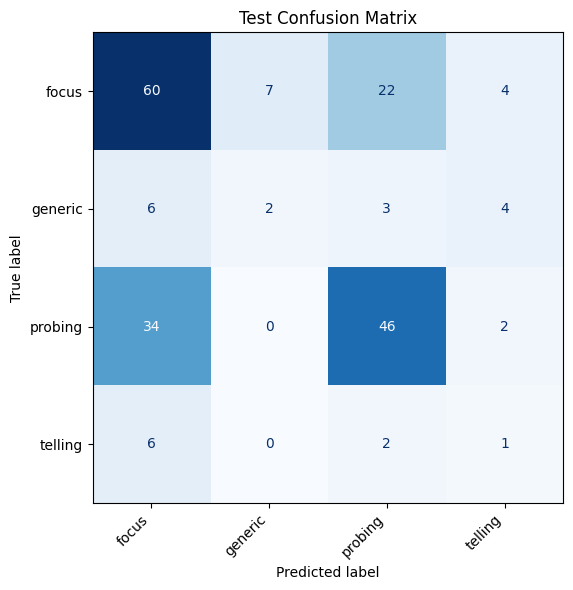

In [23]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(true_labels, pred_labels, num_labels, label_names, title="Test Confusion Matrix"):
    # Calculate confusion matrix
    cm = confusion_matrix(true_labels, pred_labels, labels=np.arange(num_labels))

    # Visualize confusion matrix
    fig, ax = plt.subplots(figsize=(7, 6))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(test_true, test_pred, num_labels, label_names)

## 10. Save Model

In [24]:
trainer.save_model(MODEL_OUT_DIR)
tokenizer.save_pretrained(MODEL_OUT_DIR)

print("\nSaved model to ", MODEL_OUT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved model to  .model/focal/all_turns/best_model


## 11. Disconnect Colab Sessions (if applicable)

In [25]:
import os
import platform
import shutil
import subprocess

import psutil

def run_command(command: list[str]) -> str | None:
    try:
        result = subprocess.run(
            command,
            capture_output=True,
            text=True,
            check=True,
        )
        return result.stdout.strip()

    except (FileNotFoundError, subprocess.CalledProcessError):
        return None


def get_colab_machine_info() -> dict:
    # CPU Information
    cpu_model = run_command(
        ["bash", "-c", "lscpu | grep 'Model name' | cut -d ':' -f 2-"]
    )

    # GPU Information
    gpu_info = run_command(
        [
            "nvidia-smi",
            "--query-gpu=name,memory.total,driver_version",
            "--format=csv,noheader",
        ]
    )

    # Memory and Disk Information
    memory = psutil.virtual_memory()
    disk = shutil.disk_usage("/")

    return {
        "system": platform.system(),
        "machine_architecture": platform.machine(),
        "cpu_model": cpu_model.strip() if cpu_model else "Unknown",
        "cpu_count": os.cpu_count(),
        "ram_total_gb": round(memory.total / 1024**3, 2),
        "ram_available_gb": round(memory.available / 1024**3, 2),
        "disk_total_gb": round(disk.total / 1024**3, 2),
        "disk_free_gb": round(disk.free / 1024**3, 2),
        "gpu": gpu_info or "gpu not available",
    }

In [26]:
if IN_COLAB:
    machine_info = get_colab_machine_info()

    for key, value in machine_info.items():
        print(f"{key}: {value}")

    with open("/proc/uptime", "r") as file:
      uptime_seconds = float(file.readline().split()[0])

    runtime_minutes = uptime_seconds / 60
    print(f"Current runtime: {runtime_minutes:.1f}분")

    from google.colab import runtime
    runtime.unassign()


system: Linux
machine_architecture: x86_64
cpu_model: AMD EPYC 9B45
cpu_count: 48
ram_total_gb: 176.88
ram_available_gb: 170.39
disk_total_gb: 235.68
disk_free_gb: 173.98
gpu: NVIDIA RTX PRO 6000 Blackwell Server Edition, 97887 MiB, 580.82.07
Current runtime: 8.1분
